*FCEIA - Tec. Universitaria en Inteligencia Artificial - Minería de Datos*

---
# **Aprendizaje supervizado**: Clasificación
# Máquina de Soporte Vectorial (SVM)

La clasificación supervizada con SVM consiste en encontrar el **hiperplano óptimo** que separa *dos clases* en el espacio de variables, maximizando el **margen** entre ellas. Los puntos más cercanos al hiperplano se denominan **vectores soporte** y definen la frontera de decisión.

Aunque SVM fue diseñado originalmente para **clasificación binaria**, puede extenderse a problemas multiclase mediante estrategias como:
- One-vs-One (OVO): compara cada par de clases.
- One-vs-Rest (OVR): compara cada clase contra todas las demás.


🎯 El objetivo de este notebook es poner en práctica la teoría de SVM y ver algunas consideraciones a la hora de implementar estos modelos.

# ⚙️ Configuración

In [1]:
import os

# Análisis exploratorio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pylab as pl

# Estilo de gráficas
plt.rcParams['figure.figsize'] = (12,  6)

# Preparación de los datos
from sklearn.datasets import load_wine
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     validation_curve)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
import sklearn.datasets as datasets

# Clasificador SVM
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay ,classification_report)
import warnings
warnings.filterwarnings('ignore')

def target_balance(y):
    """Visualizar el balance de clases"""
    cantidad = y.value_counts()
    porcentaje = y.value_counts(normalize=True) * 100

    balance = pd.DataFrame({
        'Cantidad': cantidad,
        'Porcentaje': porcentaje.map('{:.0f}%'.format)
    })

    print(f"Balance de '{y.name}':")
    print(balance.to_markdown(numalign="left", stralign="left",
                              tablefmt="simple"))

def tableResult(label, prediction):
    """Visualizar resultados"""
    print("\n-------------- Reporte --------------")
    print(classification_report(label, prediction))

    # Confusion Matrix
    cm = confusion_matrix(label, prediction)
    plt.figure(figsize=(8, 6))

    class_labels = sorted(label.unique())

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels,
                cbar=False)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de confusión')
    plt.show()

def eval_svc(model, X, y):
  y_pred = model.predict(X)
  disp = ConfusionMatrixDisplay.from_predictions(y, y_pred, cmap=plt.cm.Blues,
                                                 colorbar=False)
  disp.ax_.set_title('Clases de vino')
  disp.ax_.set_xlabel('Predicción')
  disp.ax_.set_ylabel('Real')
  plt.show()
  print("\n")
  print(classification_report(y, y_pred))

def plot_svc_decision_function(model, X0, Y0, y0, features= ['0', '1']):
  """Graficar hiperplano de desición en 2D"""
  target_names = ['class_0', 'class_1', 'class_2']
  x = np.linspace(np.min(X0) - 0.5, np.max(X0) + 0.5, 200)
  y = np.linspace(np.min(Y0) - 0.5, np.max(Y0) + 0.5, 200)
  Y, X = np.meshgrid(y, x)
  grid = np.vstack([X.ravel(), Y.ravel()]).T

  # Creamos una grilla con los colores de cada clase
  Z = model.predict(grid)
  Z = Z.reshape(X.shape)

  fig, ax = plt.subplots(figsize=(10, 8))

  # Graficamos regiones
  ax.contourf(X, Y, Z, alpha = 0.2, cmap=plt.cm.viridis)

  # Graficamos las muestras
  muestras = ax.scatter(X0, Y0, c = y0, edgecolors='k', cmap=plt.cm.viridis)

  # Graficamos vecotres soporte
  soportes = ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=200,
             linewidth=1, facecolors='none', edgecolors='black', label='Vectores Soporte')

  # Creamos legendas
  handles_classes, labels_classes = muestras.legend_elements()
  labels_classes = [target_names[int(label.replace('$\mathdefault{', '').replace('}$', ''))] for label in labels_classes]

  all_handles = handles_classes + [soportes]
  all_labels = labels_classes + ['Vectores Soporte']

  ax.contour(X, Y, model.decision_function(grid).reshape(X.shape), colors = 'k',
             levels = [-1, 0, 1], alpha = 0.5, linestyles = ['--', '-', '--'])

  ax.set_xlabel(features[0])
  ax.set_ylabel(features[1])
  ax.set_title('Hiperplano de desición')
  ax.legend(all_handles, all_labels, title="Clases de Vino")
  ax.grid(True)
  plt.show()

<>:99: SyntaxWarning: invalid escape sequence '\m'
<>:99: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5567/2349180501.py:99: SyntaxWarning: invalid escape sequence '\m'
  labels_classes = [target_names[int(label.replace('$\mathdefault{', '').replace('}$', ''))] for label in labels_classes]


# 📂 Base de datos
## *Clases de Vinos*

Estos datos son el resultado de un análisis químico de 3 tipos de vinos cultivados en la misma región de Italia. El
análisis determinó las cantidades de 13 componentes presentes en cada uno de
los tres tipos de vino.

Fuente de datos: Aeberhard,Stefan y Forina,M. (1991). Wine. UCI Machine
Learning Repository. https://doi.org/10.24432/C5PC7J.

Contiene las **Variables descriptivas** de la composición química y propiedades del vino:

1. Alcohol [%]
2. Ácido málico [g/L]
3. Cenizas [g/L]
4. Alcalinidad de las cenizas [meq/L]
5. Magnesio [mg/L]
6. Fenoles totales [g/L]
7. Flavonoides [g/L]
8. Fenoles no flavonoides [g/L]
9. Proantocianinas [g/L]
10. Intensidad del color [Unidades de Absorbancia]
11. Tonalidad [relación de absorbancia]
12. ODO280/ODO315 de los vinos diluidos [relación]
13. Prolina [mg/L]

In [2]:
X, y = datasets.load_wine(return_X_y=True, as_frame=True)

# 📊 Estructura
Nombre de variables, variable objetivo, tipos de datos y valores nulos.

In [3]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
# Obtener información general sobre el DataFrame
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [5]:
# Obtener estadísticas descriptivas
X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
y.name

'target'

In [7]:
target_balance(y)

Balance de 'target':
target    Cantidad    Porcentaje
--------  ----------  ------------
1         71          40%
0         59          33%
2         48          27%


# ✅ Conjunto de prueba

In [8]:
# Obtengo datos de entrenamiento y de testeo
Xtrn, Xtst, ytrn, ytst  = train_test_split(X, y, test_size=0.2,
                            random_state=42, shuffle=True, stratify=y)

# 🔍 Análisis exploratorio

In [9]:
# Hay duplicados?
print(Xtrn.duplicated().values.any())

False


## Correlación de variables

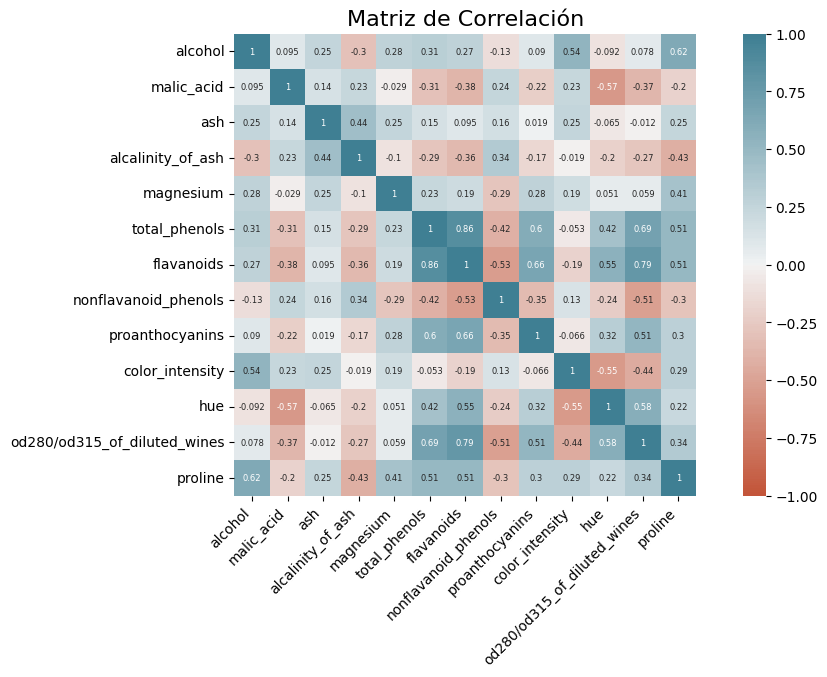

In [10]:
corr = Xtrn.corr(method='pearson')
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

## Distribución de variables


In [11]:
sns.pairplot(pd.concat([Xtrn, ytrn], axis=1), hue='target')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

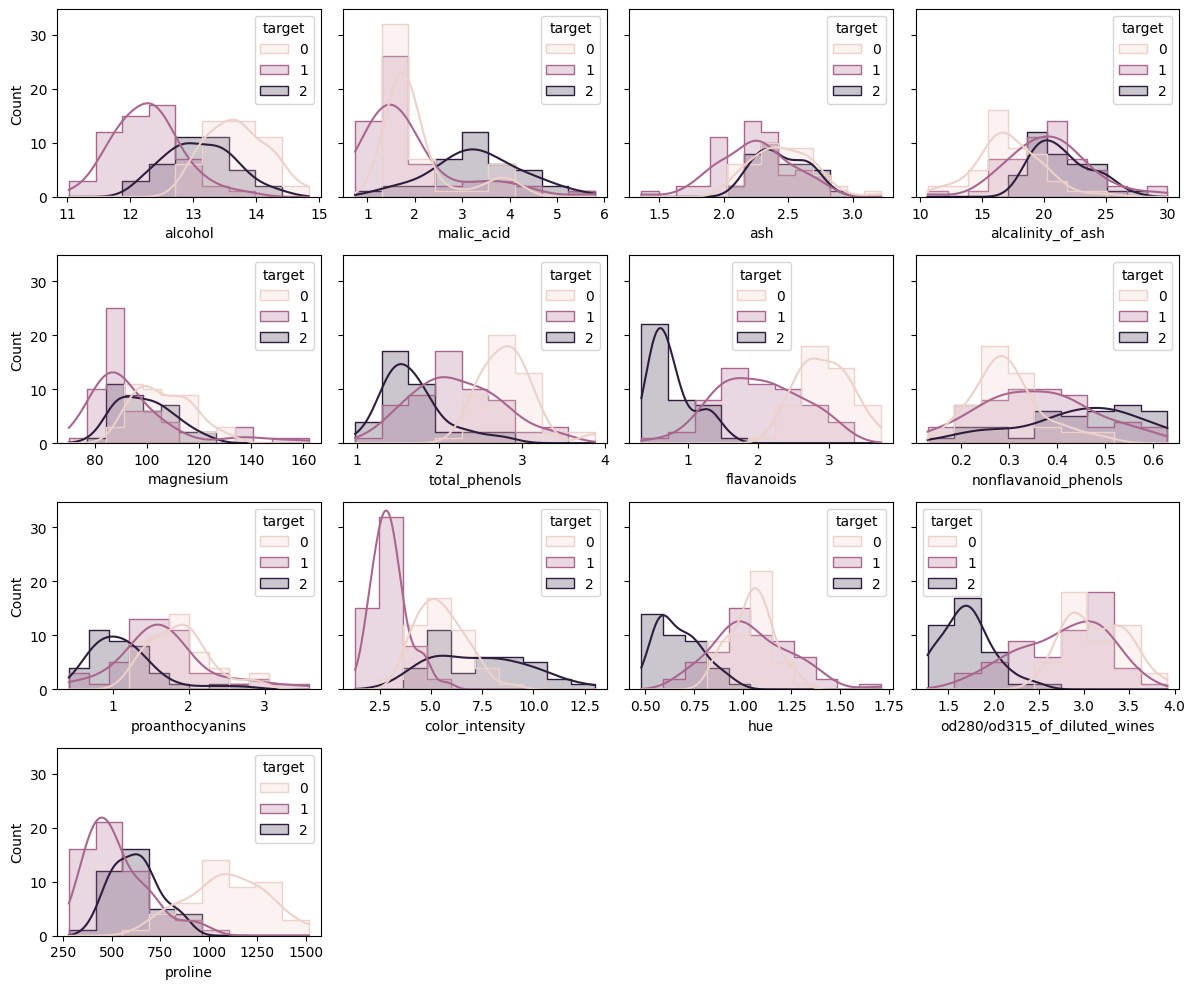

In [12]:
cols = Xtrn.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(nrows=4, ncols=4, sharey=True,
                         figsize=(12, 10))
for i, col in enumerate(cols, 1):
    sns.histplot(data=pd.concat([Xtrn, ytrn], axis=1), x=col, hue='target',
                 kde=True, element='step', ax=axes.flatten()[i-1])

for i in range(len(cols)+1, 17):
    axes.flatten()[i-1].axis('off')

plt.tight_layout()
plt.show()

# Preparación de los datos

## Escalado
Las SVM encuentran mejores fronteras cuando los datos están normalizados.


In [13]:
scaler = StandardScaler().set_output(transform="pandas")
Xtrn_std = Xtrn.copy()
Xtst_std = Xtst.copy()
Xtrn_std = scaler.fit_transform(Xtrn)
Xtst_std = scaler.transform(Xtst)

# SVM Lineal
Como vimos, SVM realiza clasificaciones binarias por medio de un hiperplano.


Observemos cómo se distribuyen dos de nuestras variables descriptivas: **Intensidad de Color** y **Flavonoides**.

1. Observando el gráfico: ¿Creen que una línea recta podrá separar perfectamente las tres clases de vino?
2. ¿Qué clase (0, 1 o 2) parece más fácil de aislar del resto?

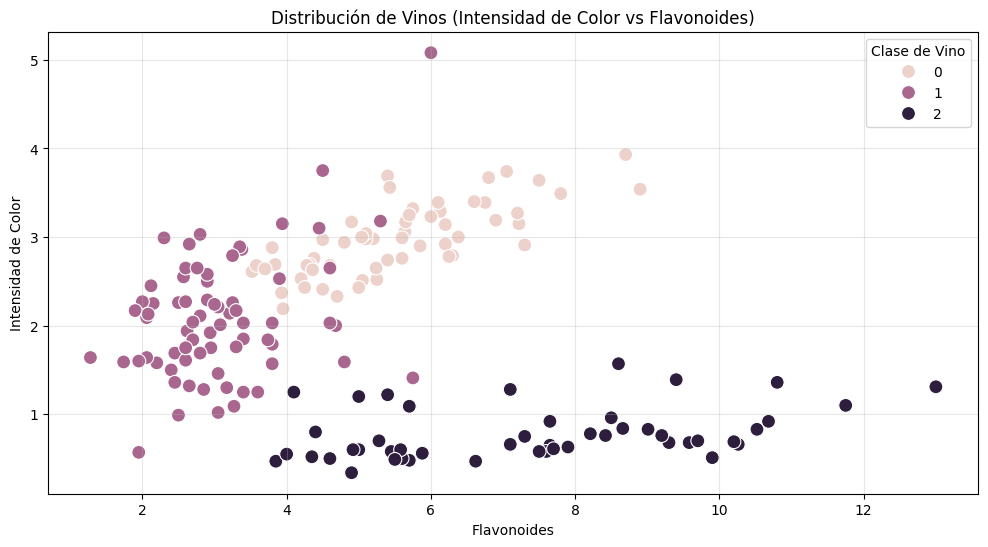

In [14]:
plt.figure()
scatter = sns.scatterplot(data=X, x='color_intensity', y='flavanoids', hue=y,
                          s=100)
plt.title('Distribución de Vinos (Intensidad de Color vs Flavonoides)')
plt.xlabel('Flavonoides')
plt.ylabel('Intensidad de Color')
plt.legend(title='Clase de Vino')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Seleccionamos clae 1 y 2
BDTrn = ytrn != 0
BDTst = ytst != 0

## LinearSVC o SVC?
`LinearSVC` es una buena opción cuando se necesita precisión, pero no acepta kernels.

`SVC` es útil cuando se tienen datos que no son linealmente separables, aplicando kernels.

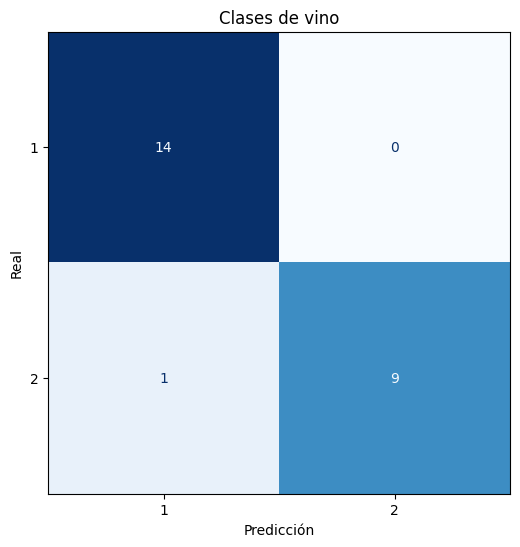



              precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.96        24
   macro avg       0.97      0.95      0.96        24
weighted avg       0.96      0.96      0.96        24



In [16]:
# Definición del Modelo
svm_classifier_linear = SVC(kernel='linear', C=1)

# Entrenamiento
svm_classifier_linear.fit(Xtrn_std[BDTrn], ytrn[BDTrn])
eval_svc(svm_classifier_linear, Xtst_std[BDTst], ytst[BDTst])

¿Cuál es la clase que más confunde al modelo y por qué creen que sucede esto?

## Visualización del hiperplano
Elijo y visualizo las variables a clasificar.

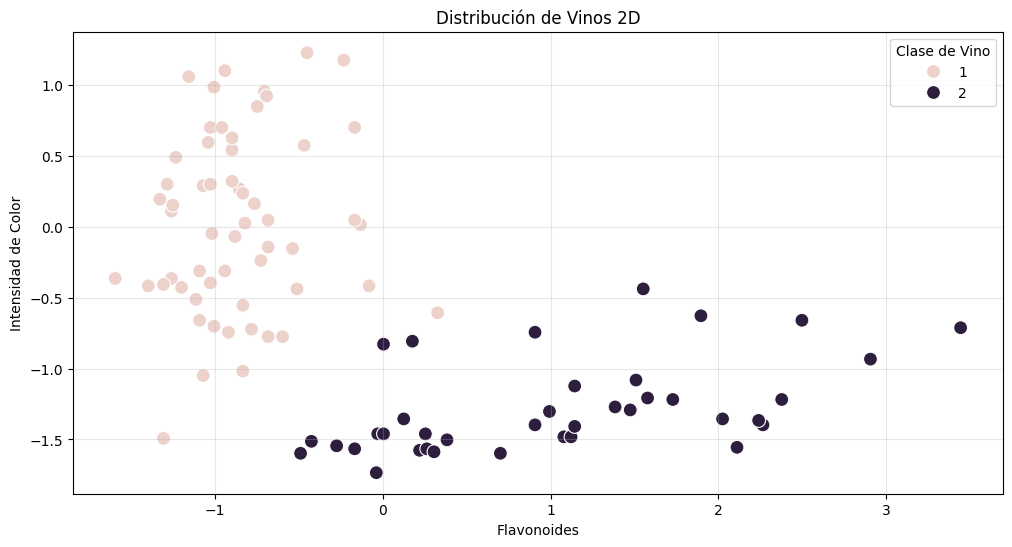

In [17]:
bidim = ['color_intensity', 'flavanoids']
plt.figure()
sns.scatterplot(data=Xtrn_std[BDTrn][bidim], x=bidim[0], y=bidim[1],
                hue=ytrn[BDTrn], s=100)
plt.title('Distribución de Vinos 2D')
plt.xlabel('Flavonoides')
plt.ylabel('Intensidad de Color')
plt.legend(title='Clase de Vino')
plt.grid(True, alpha=0.3)
plt.show()

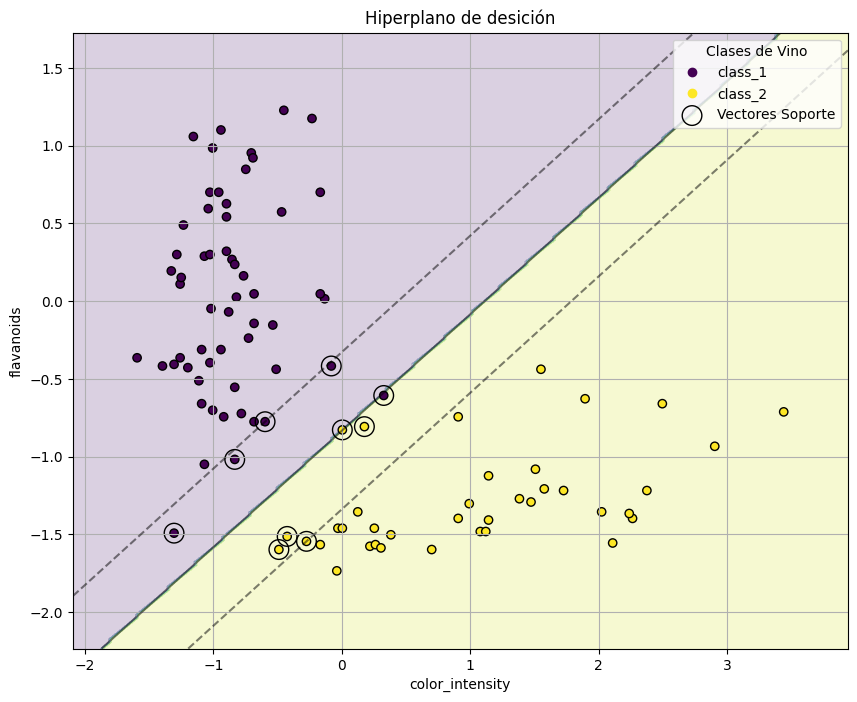

In [18]:
svm_classifier_linear.fit(Xtrn_std[BDTrn][bidim], ytrn[BDTrn])
plot_svc_decision_function(svm_classifier_linear, Xtrn_std[BDTrn][bidim[0]],
                           Xtrn_std[BDTrn][bidim[1]], ytrn[BDTrn], bidim)

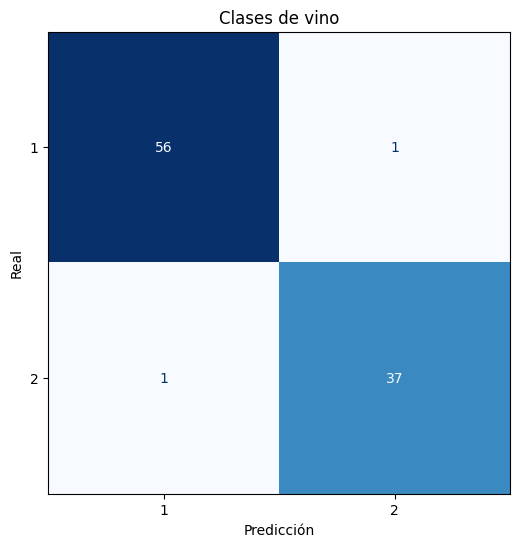



              precision    recall  f1-score   support

           1       0.98      0.98      0.98        57
           2       0.97      0.97      0.97        38

    accuracy                           0.98        95
   macro avg       0.98      0.98      0.98        95
weighted avg       0.98      0.98      0.98        95



In [19]:
eval_svc(svm_classifier_linear, Xtrn_std[BDTrn][bidim], ytrn[BDTrn])

Como vimos en la teoría, el parámetro **C** controla la penalización por error (lo que llamamos *Soft Margin*):

Modifiquen el valor de C en la siguiente celda. Prueben C=0.01, C=100 y C=1000.
- ¿Qué le pasa al ancho de la 'calle' (margen)?
- ¿Qué pasa con los puntos que quedan dentro del margen?
- ¿Los vectores soporte aumentan o disminuyen?

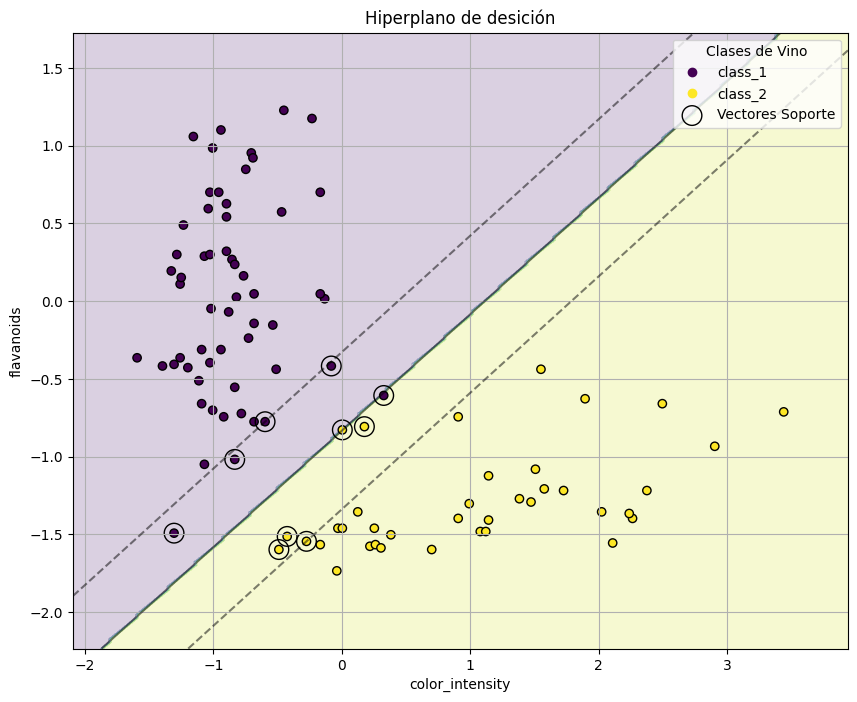

In [20]:
valor_C = 1
model_exp = SVC(kernel='linear', C=valor_C)
model_exp.fit(Xtrn_std[BDTrn][bidim], ytrn[BDTrn])
plot_svc_decision_function(model_exp, Xtrn_std[BDTrn][bidim[0]],
                           Xtrn_std[BDTrn][bidim[1]], ytrn[BDTrn], bidim)

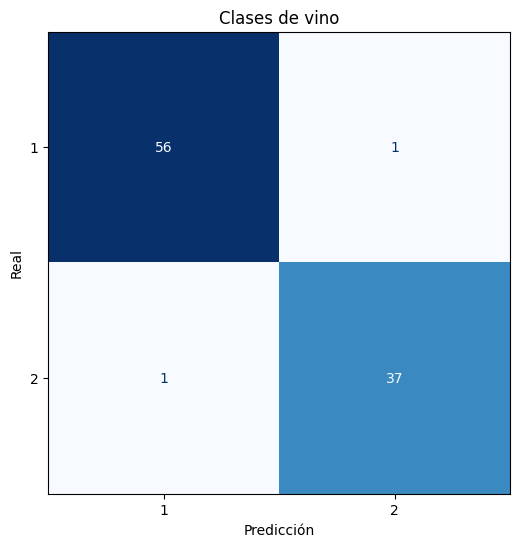



              precision    recall  f1-score   support

           1       0.98      0.98      0.98        57
           2       0.97      0.97      0.97        38

    accuracy                           0.98        95
   macro avg       0.98      0.98      0.98        95
weighted avg       0.98      0.98      0.98        95



In [21]:
eval_svc(model_exp, Xtrn_std[BDTrn][bidim], ytrn[BDTrn])

In [22]:
print(f'Vector de pesos (w) = [{model_exp.coef_[0][0]:.2f} {model_exp.coef_[0][1]:.2f}]')
print(f'b = {model_exp.intercept_[0]:.2f}')
print('Indices de vectores de soporte = ', model_exp.support_)
print('Vectores de soporte = ')
for vec in model_exp.support_vectors_:
    print(f'  [{vec[0]:.2f} {vec[1]:.2f}]')
print('Numero de vectores de soporte por cada clase = ', model_exp.n_support_)
dual_coef_vals = np.abs(model_exp.dual_coef_).flatten()
dual_coef_formatted = ' '.join([f'{c:.2f}' for c in dual_coef_vals])
print(f'Coeficientes del vector de soporte en la \nfuncion de decisión = [{dual_coef_formatted}]')

Vector de pesos (w) = [1.48 -1.98]
b = -1.65
Indices de vectores de soporte =  [22 37 58 60 76  6 26 48 91 94]
Vectores de soporte = 
  [-0.08 -0.42]
  [-0.60 -0.78]
  [-0.83 -1.02]
  [0.33 -0.61]
  [-1.31 -1.49]
  [0.00 -0.83]
  [-0.43 -1.51]
  [-0.49 -1.60]
  [-0.27 -1.54]
  [0.18 -0.81]
Numero de vectores de soporte por cada clase =  [5 5]
Coeficientes del vector de soporte en la 
funcion de decisión = [1.00 1.00 1.00 1.00 1.00 1.00 1.00 1.00 1.00 1.00]


¿Qué pasa con la frontera de decisión cuando aumentamos el valor de C? ¿Estamos sobreajustando (overfitting)?

¿Si borramos todos los puntos del dataset EXCEPTO los vectores de soporte, el hiperplano cambiaría?

## Evaluación de funciones kernels
En la [documentación](https://scikit-learn.org/stable/modules/svm.html#kernel-functions) pueden ver en detalle que hiperparámetro afecta a cada kernel y como [definir su propio kernel](https://scikit-learn.org/stable/auto_examples/svm/plot_custom_kernel.html)

### Polinomial

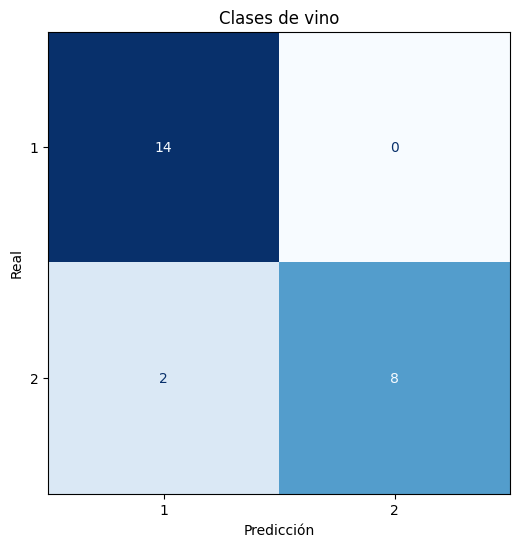



              precision    recall  f1-score   support

           1       0.88      1.00      0.93        14
           2       1.00      0.80      0.89        10

    accuracy                           0.92        24
   macro avg       0.94      0.90      0.91        24
weighted avg       0.93      0.92      0.91        24



In [23]:
# Definición del Modelo
svm_classifier_poly = SVC(kernel='poly', C=0.1, degree=3, coef0=2)
# Entrenamiento y evaluación
svm_classifier_poly.fit(Xtrn_std[BDTrn], ytrn[BDTrn])
eval_svc(svm_classifier_poly, Xtst_std[BDTst], ytst[BDTst])

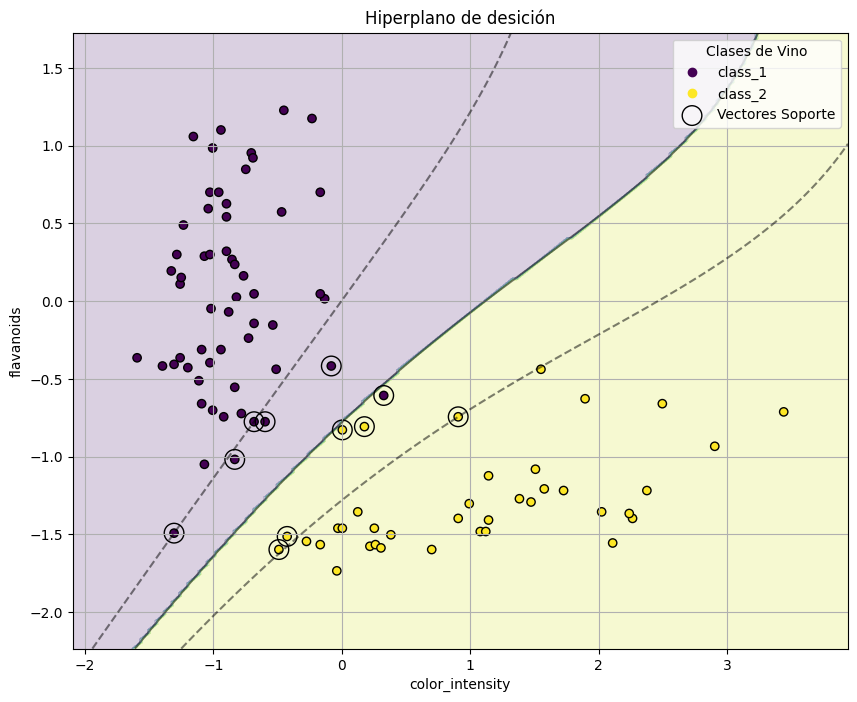

In [24]:
svm_classifier_poly.fit(Xtrn_std[BDTrn][bidim], ytrn[BDTrn])
plot_svc_decision_function(svm_classifier_poly, Xtrn_std[BDTrn][bidim[0]],
                           Xtrn_std[BDTrn][bidim[1]], ytrn[BDTrn], bidim)

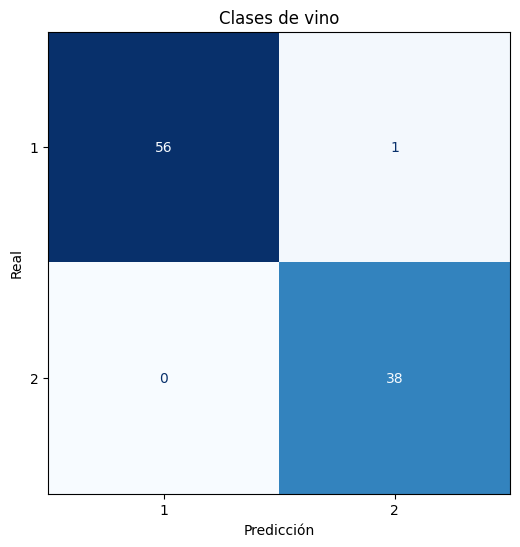



              precision    recall  f1-score   support

           1       1.00      0.98      0.99        57
           2       0.97      1.00      0.99        38

    accuracy                           0.99        95
   macro avg       0.99      0.99      0.99        95
weighted avg       0.99      0.99      0.99        95



In [25]:
eval_svc(svm_classifier_poly, Xtrn_std[BDTrn][bidim], ytrn[BDTrn])

### Funcion de base radial (RBF) gaussiana

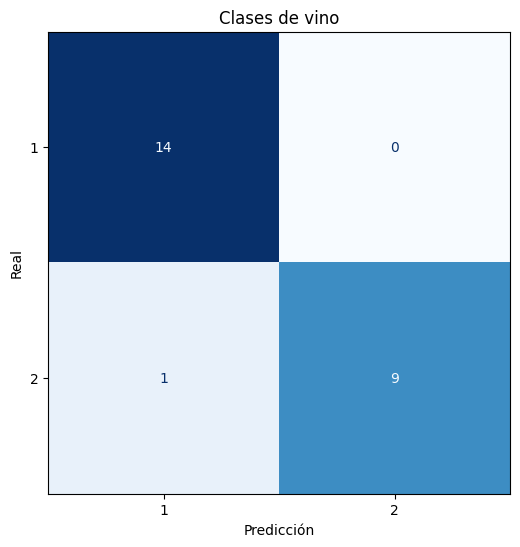



              precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.96        24
   macro avg       0.97      0.95      0.96        24
weighted avg       0.96      0.96      0.96        24



In [26]:
svm_classifier_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_classifier_rbf.fit(Xtrn_std[BDTrn], ytrn[BDTrn])
eval_svc(svm_classifier_rbf, Xtst_std[BDTst], ytst[BDTst])

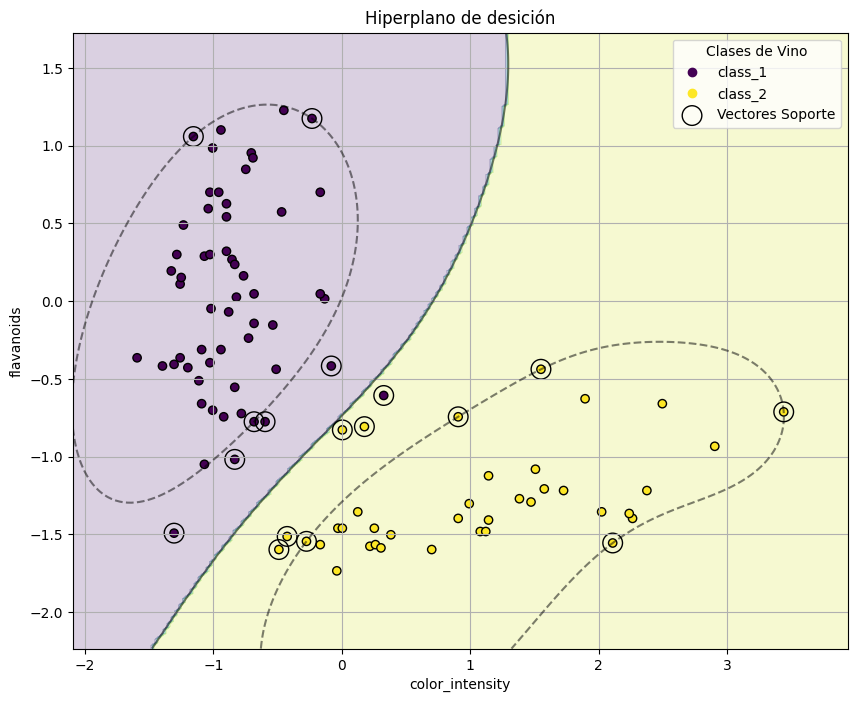

In [27]:
svm_classifier_rbf.fit(Xtrn_std[BDTrn][bidim], ytrn[BDTrn])
plot_svc_decision_function(svm_classifier_rbf, Xtrn_std[BDTrn][bidim[0]],
                           Xtrn_std[BDTrn][bidim[1]], ytrn[BDTrn], bidim)

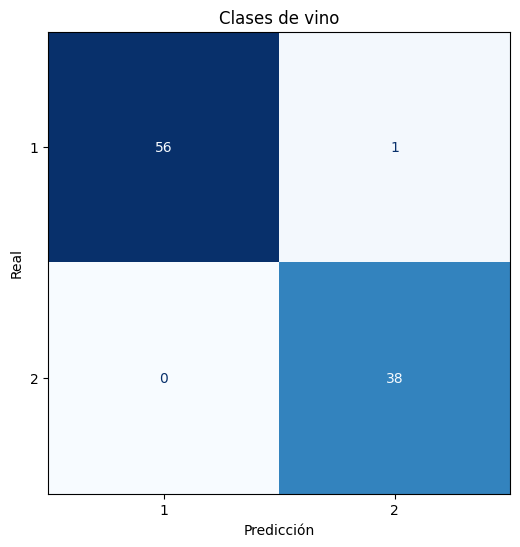



              precision    recall  f1-score   support

           1       1.00      0.98      0.99        57
           2       0.97      1.00      0.99        38

    accuracy                           0.99        95
   macro avg       0.99      0.99      0.99        95
weighted avg       0.99      0.99      0.99        95



In [28]:
eval_svc(svm_classifier_rbf, Xtrn_std[BDTrn][bidim], ytrn[BDTrn])

### Sigmoideo

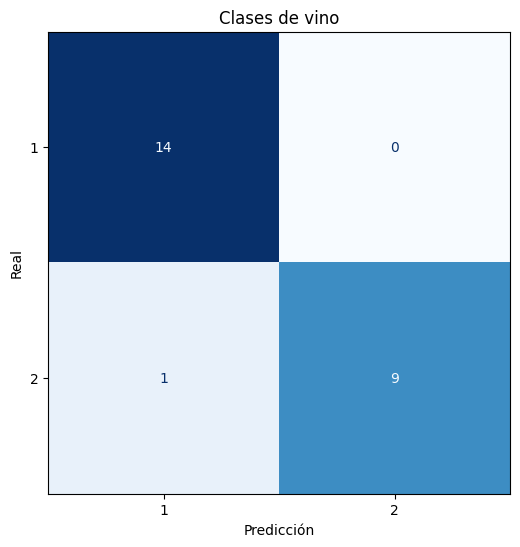



              precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.96        24
   macro avg       0.97      0.95      0.96        24
weighted avg       0.96      0.96      0.96        24



In [29]:
svm_classifier_sigmoid = SVC(kernel='sigmoid', C=1.0, gamma='scale', coef0=0.0)
svm_classifier_sigmoid.fit(Xtrn_std[BDTrn][bidim], ytrn[BDTrn])
eval_svc(svm_classifier_sigmoid, Xtst_std[BDTst][bidim], ytst[BDTst])

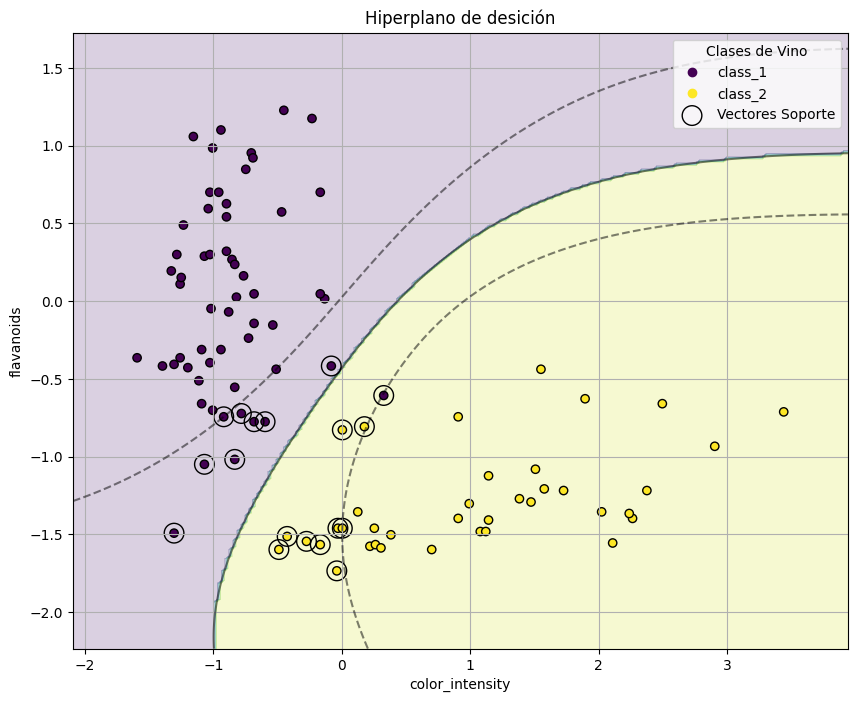

In [30]:
svm_classifier_sigmoid.fit(Xtrn_std[BDTrn][bidim], ytrn[BDTrn])
plot_svc_decision_function(svm_classifier_sigmoid, Xtrn_std[BDTrn][bidim[0]],
                           Xtrn_std[BDTrn][bidim[1]], ytrn[BDTrn], bidim)

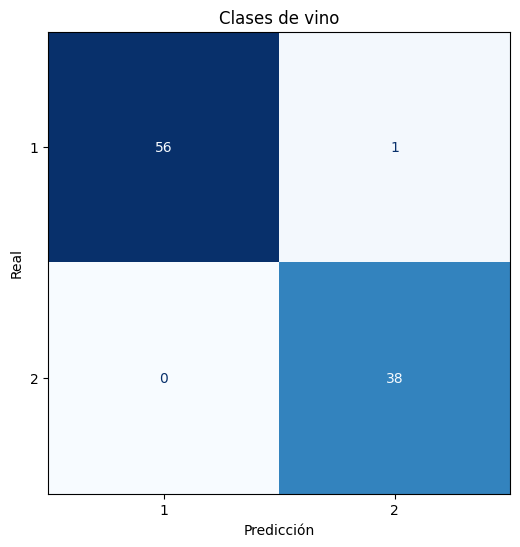



              precision    recall  f1-score   support

           1       1.00      0.98      0.99        57
           2       0.97      1.00      0.99        38

    accuracy                           0.99        95
   macro avg       0.99      0.99      0.99        95
weighted avg       0.99      0.99      0.99        95



In [31]:
eval_svc(svm_classifier_sigmoid, Xtrn_std[BDTrn][bidim], ytrn[BDTrn])

# SVM Multiclase




### El "Kernel Trick" y Clasificación Multiclase
Cuando utilizamos las 13 variables y las 3 clases simultáneamente, el problema deja de ser linealmente separable en el espacio original. Sklearn implementa por defecto la estrategia **One-vs-Rest (OVR)** para abordar el problema multiclase.

Provemos cada `kernel`:
- **A:** `'linear'`
- **B:** `'poly'`
- **C:** `'rbf'`

Observen la **Matriz de Confusión** generada por nuestra función `tableResult`.
- ¿Qué kernel logra separar mejor a los vinos? - ¿Cuál es la clase de vino que más se confunde (falsos positivos/negativos)?

## Optimización del modelo

In [32]:
# Hiperparámetros de búsqueda
params_grid = [{'kernel': ['rbf'], 'gamma': [1e-3, 1e-4],
                'C': [0.1, 1, 10, 100, 1000]},
                 {'kernel': ['linear'], 'C': [0.1, 1, 10, 100, 1000]}]

In [33]:
# Aplicar la búsqueda de grilla para elegir los mejores hiperparámetros
svm_model = GridSearchCV(SVC(), params_grid, cv=5)
svm_model.fit(Xtrn_std, ytrn)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [0.1, 1, 10, 100, 1000],
                          'gamma': [0.001, 0.0001], 'kernel': ['rbf']},
                         {'C': [0.1, 1, 10, 100, 1000], 'kernel': ['linear']}])

In [34]:
# Mejor modelo
print('C:',svm_model.best_estimator_.C,"\n")
print('Kernel:',svm_model.best_estimator_.kernel,"\n")
print('Gamma:',svm_model.best_estimator_.gamma,"\n")
print('Score:', svm_model.best_score_,"\n")

C: 1000 

Kernel: rbf 

Gamma: 0.001 

Score: 0.9862068965517242 



In [35]:
from sklearn.model_selection import ValidationCurveDisplay, validation_curve
param_name, param_range = "C", np.logspace(-2, 10, 13)
train_scores, test_scores = validation_curve(svm_model.best_estimator_, Xtrn,
                                             ytrn, param_name=param_name,
                                             param_range=param_range)


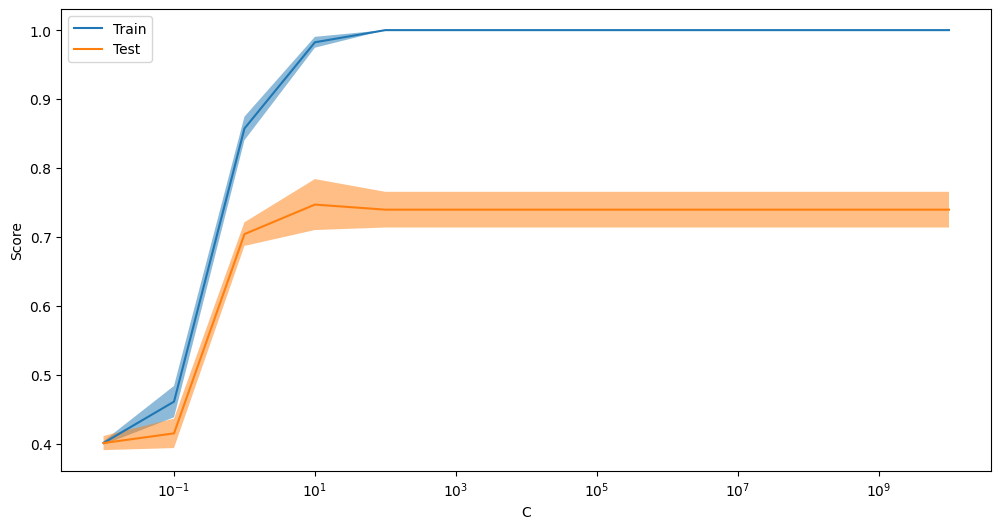

In [36]:
display = ValidationCurveDisplay(param_name=param_name, param_range=param_range,
    train_scores=train_scores, test_scores=test_scores, score_name="Score")
display.plot()

## Evaluación

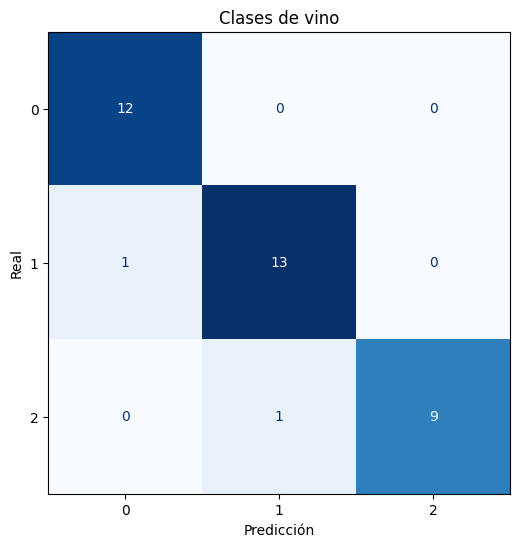



              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [37]:
eval_svc(svm_model.best_estimator_, Xtst_std, ytst)

## Visualización 2D

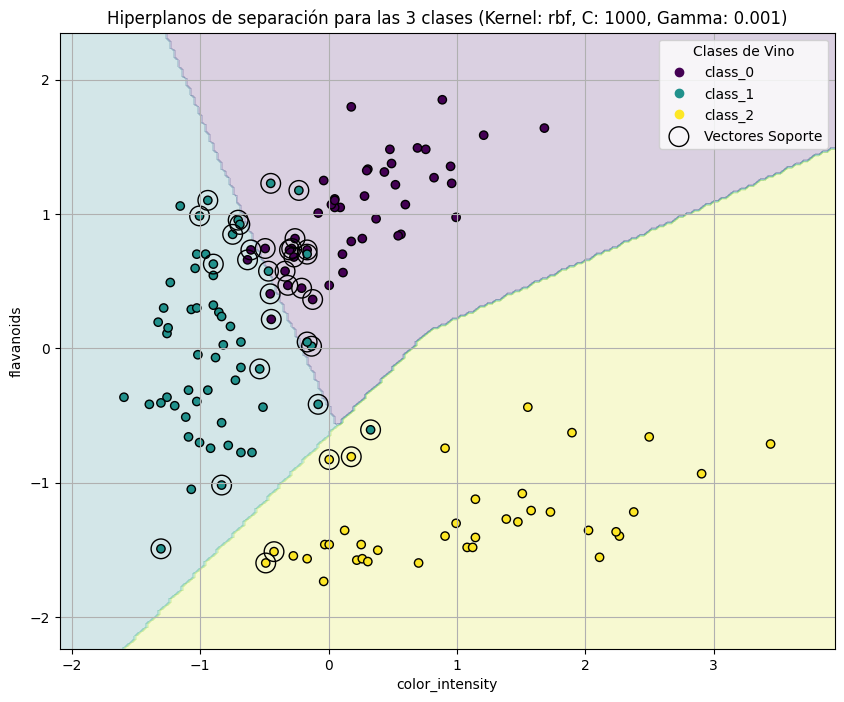

In [38]:
target_names = ['class_0', 'class_1', 'class_2']
# Obtenemos los hiperparámetros
best_params = svm_model.best_estimator_.get_params()

# Creamos un modelo para 2 dimensiones
model_multi2D = SVC(kernel=best_params['kernel'], C=best_params['C'],
                           gamma=best_params['gamma'])

# Elejimos las variables descriptivas a visualizar
bidim = ['color_intensity', 'flavanoids']
model_multi2D.fit(Xtrn_std[bidim], ytrn)

# Realizamos los mismos pasos que en clasificación binaria
x_min, x_max = Xtrn_std[bidim][bidim[0]].min() - 0.5, Xtrn_std[bidim][bidim[0]].max() + 0.5
y_min, y_max = Xtrn_std[bidim][bidim[1]].min() - 0.5, Xtrn_std[bidim][bidim[1]].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Creamos una grilla con los colores de cada clase
Z = model_multi2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))

# Graficamos las regiones
ax.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.viridis)

# Graficamos las muestras
scatter = ax.scatter(Xtrn_std[bidim][bidim[0]], Xtrn_std[bidim][bidim[1]], c=ytrn,
              edgecolors='k', cmap=plt.cm.viridis)

# Creamos legendas
handles_classes, labels_classes = scatter.legend_elements()
labels_classes = [target_names[int(label.replace('$\mathdefault{', '').replace('}$', ''))] for label in labels_classes]

# Graficamos vectores soporte
soportes = ax.scatter(model_multi2D.support_vectors_[:, 0], model_multi2D.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='black', linewidth=1, label='Vectores Soporte')

# Combinamos legendas para clases y vectores soporte
all_handles = handles_classes + [soportes]
all_labels = labels_classes + ['Vectores Soporte']

# Gráfica final
ax.set_xlabel(bidim[0])
ax.set_ylabel(bidim[1])
ax.set_title(f'Hiperplanos de separación para las 3 clases (Kernel: {best_params['kernel']}, C: {best_params['C']}, Gamma: {best_params['gamma']})')
ax.legend(all_handles, all_labels, title="Clases de Vino")
ax.grid(True)
plt.show()

# Repaso

✅ Recomendación
- El algoritmo de SVM encuentra mejores fronteras de desicision con datos normalizados.

### ¿Qué es un SVM?
Un **Máquina de Vectores de Soporte (SVM)** busca encontrar un **hiperplano óptimo** que separe las clases con el mayor margen posible. Esto permite una separación más robusta frente al ruido.

### ¿Por qué es útil?
- Funciona bien incluso con datos no linealmente separables usando **kernels**.
- Controla la complejidad mediante el hiperparámetro `C` y `Gamma`.
- Eficiente en conjunto de datos multidimensionales.

### Hiperparámetros clave
- **C muy pequeño (ej. 0.01):** El modelo es más permisivo, creando un margen ancho pero cometiendo más errores de clasificación (mayor generalización).
- **C muy grande (ej. 1000):** El modelo penaliza fuertemente los errores, creando un margen estricto que intenta ajustarse a cada punto (riesgo de *overfitting*).
- **Kernel**: lineal, rbf, polinomial.
- **Gamma**: para kernels no lineales; regula influencia de los puntos.

In [38]:
Probemos cada kernel